In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv('../dataset/ghi_temp.csv')

In [3]:
df.head()


,Year,Month,Day,Hour,Minute,GHI,Temperature,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2019,1,1,0,0,0,16.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,1,1,1,0,0,16.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,1,2,0,0,16.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,1,3,0,0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,1,4,0,0,15.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
ghi_col = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'Temperature']
df = df[ghi_col]
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature
0,2019,1,1,0,0,0,16.3
1,2019,1,1,1,0,0,16.2
2,2019,1,1,2,0,0,16.1
3,2019,1,1,3,0,0,16.0
4,2019,1,1,4,0,0,15.9


In [5]:
df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

In [6]:
df = df[['datetime', 'GHI', 'Temperature']]

df.set_index('datetime', inplace=True)

df.head()

,GHI,Temperature
datetime,,
2019-01-01 00:00:00,0,16.3
2019-01-01 01:00:00,0,16.2
2019-01-01 02:00:00,0,16.1
2019-01-01 03:00:00,0,16.0
2019-01-01 04:00:00,0,15.9


<Axes: xlabel='datetime'>

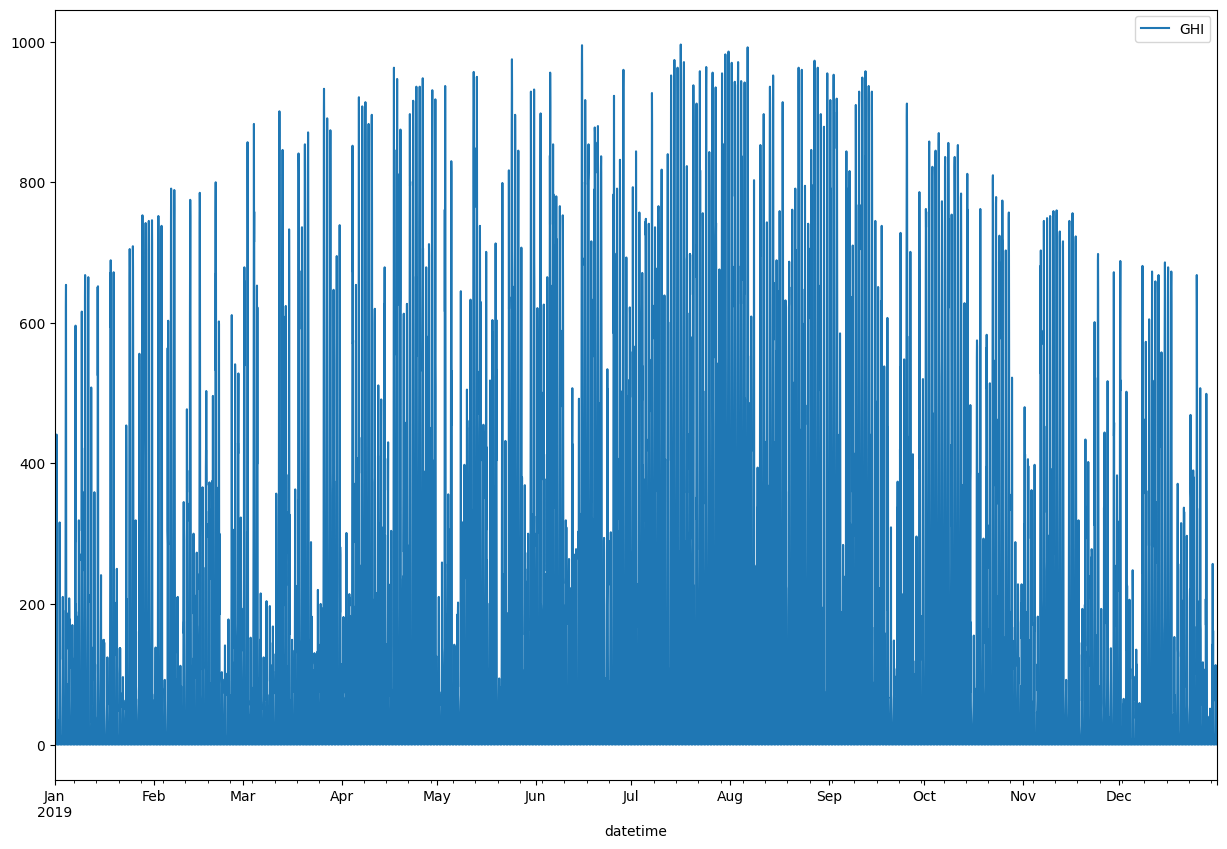

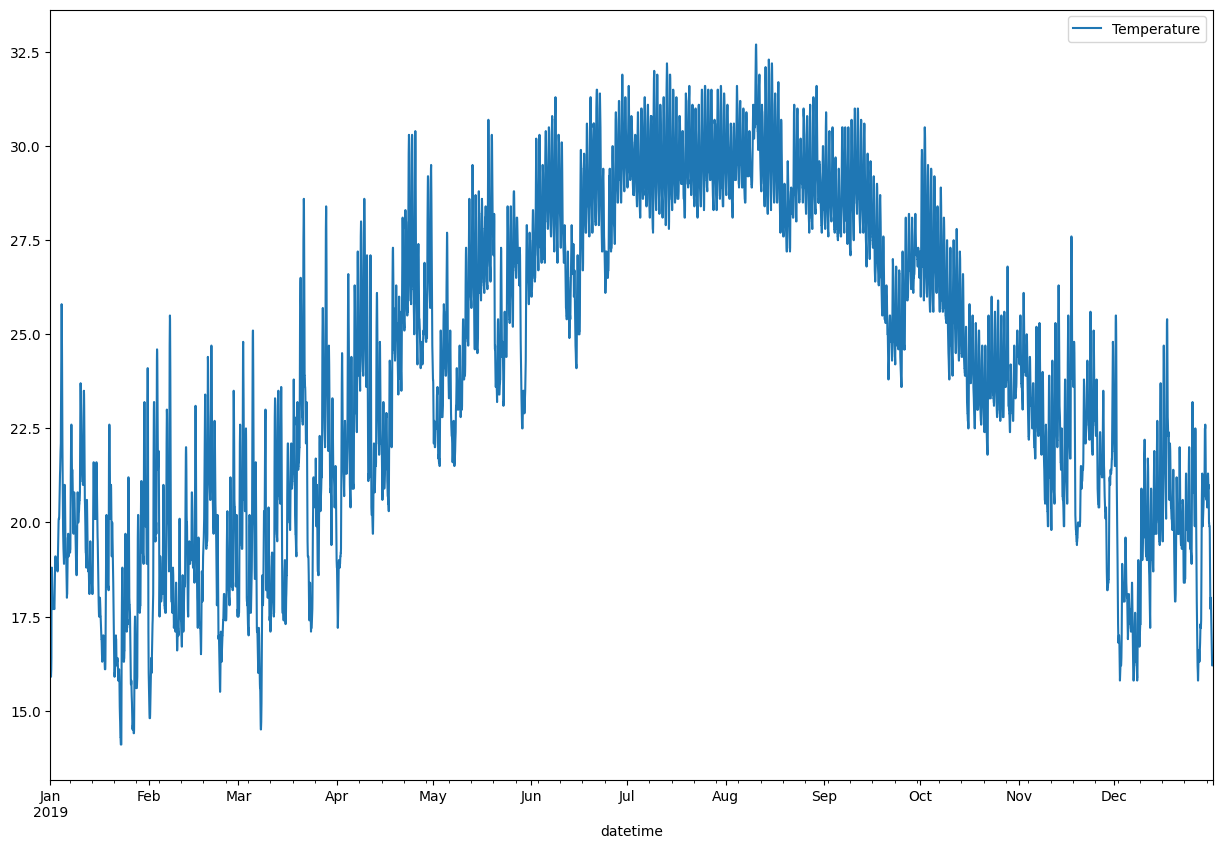

In [13]:
df.plot(y='GHI', figsize=(15,10))
df.plot(y='Temperature', figsize=(15,10))

In [11]:
print(df.columns)

Index(['GHI', 'Temperature'], dtype='object')


In [ ]:
print(df.shape)

In [ ]:
# split point agar train data hanya hingga 30 september pukul 23.00

split_point = len(df[:'2019-9-30 23:00:00'])
print(split_point)

In [ ]:
df_for_training = df[:split_point]
df_for_testing = df[split_point:]

print(df_for_training.shape)
print(df_for_testing.shape)

In [ ]:
mmscaler = MinMaxScaler(feature_range=(0, 1))
df_for_training_scaled = mmscaler.fit_transform(df_for_training)
df_for_testing_scaled = mmscaler.transform(df_for_testing)

df_for_training_scaled

In [11]:
def createXY(dataset, n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
        dataX.append(dataset[i - n_past: i, 0: dataset.shape[1]])
        dataY.append(dataset[i, 0])
    
    return np.array(dataX), np.array(dataY)

trainX, trainY = createXY(df_for_training_scaled, 24)
testX, testY = createXY(df_for_testing_scaled, 24)

In [ ]:
print(trainX.shape)
print(trainY.shape)

print(testX.shape)
print(testY.shape)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape= (trainX.shape[1], trainX.shape[2])))
model.add(LSTM(64, return_sequences= False))
model.add(Dense(24))

In [ ]:
model.summary()

In [15]:
# compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


In [16]:
grid_model = KerasRegressor(build_fn=model, verbose=1, validation_data=(testX, testY))

In [17]:
parameters = {'batch_size' : [16,20],
              'epochs' : [8,10],
              'optimizer' : ['adam','Adadelta'] }

grid_search  = GridSearchCV(estimator = grid_model,
                            param_grid = parameters,
                            cv = 2)

In [ ]:
grid_search = grid_search.fit(trainX, trainY)